In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
df=pd.read_csv('/Users/user/Downloads/INvideos.csv')

In [3]:
df.head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


In [4]:
df.shape


(37352, 16)

In [5]:
df.columns.tolist()

['video_id',
 'trending_date',
 'title',
 'channel_title',
 'category_id',
 'publish_time',
 'tags',
 'views',
 'likes',
 'dislikes',
 'comment_count',
 'thumbnail_link',
 'comments_disabled',
 'ratings_disabled',
 'video_error_or_removed',
 'description']

In [6]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [7]:
df['publish_time']=pd.to_datetime(df['publish_time'])

In [8]:
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_day']  = df['publish_time'].dt.day_name()

In [9]:
df['trending_date'] = pd.to_datetime(df['trending_date'])
df['trending_day'] = df['trending_date'].dt.day_name()

In [10]:
df['publish_month'] = df['publish_time'].dt.month_name()

In [11]:
df['days_to_trend'] = (df['trending_date'].dt.tz_localize(None) - 
                       df['publish_time'].dt.tz_localize(None).dt.normalize()).dt.days

In [12]:
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
publish_hour                0
publish_day                 0
trending_day                0
publish_month               0
days_to_trend               0
dtype: int64

In [13]:
df = df.dropna(subset=['title', 'channel_title', 'views', 'likes'])

In [14]:
df = df.drop_duplicates(subset=['video_id', 'trending_date'])

In [15]:
df = df[df['views'] > 0]
df = df[df['likes'] >= 0]

In [16]:
df['views'] = df['views'].astype(int)

In [17]:
df['like_rate'] = (df['likes'] / df['views'] * 100)

In [18]:
df['comment_rate']=(df['comment_count']/df['views']*100)

In [19]:
df['engagement_score'] = (df['like_rate'] + df['comment_rate']).round(2)

In [20]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.VirtualBox', '.wslconfig', '3D Objects', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'INTRODUCTION TO PYTHON.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'PycharmProjects', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled10.ipynb', 'Untitled11.ipynb', 'Untitled12.ipynb', 'Untitled13.ipynb', 'Untitled14.ipynb', 'Untitled15.ipyn

In [21]:
category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music",
    15: "Pets & Animals", 17: "Sports", 19: "Travel & Events",
    20: "Gaming", 22: "People & Blogs", 23: "Comedy",
    24: "Entertainment", 25: "News & Politics", 26: "Howto & Style",
    27: "Education", 28: "Science & Technology", 29: "Nonprofits & Activism"
}

df['category_name'] = df['category_id'].map(category_map)
print("Categories mapped!")
top_categories=df['category_name'].value_counts()

Categories mapped!


In [22]:
import matplotlib.pyplot as plt

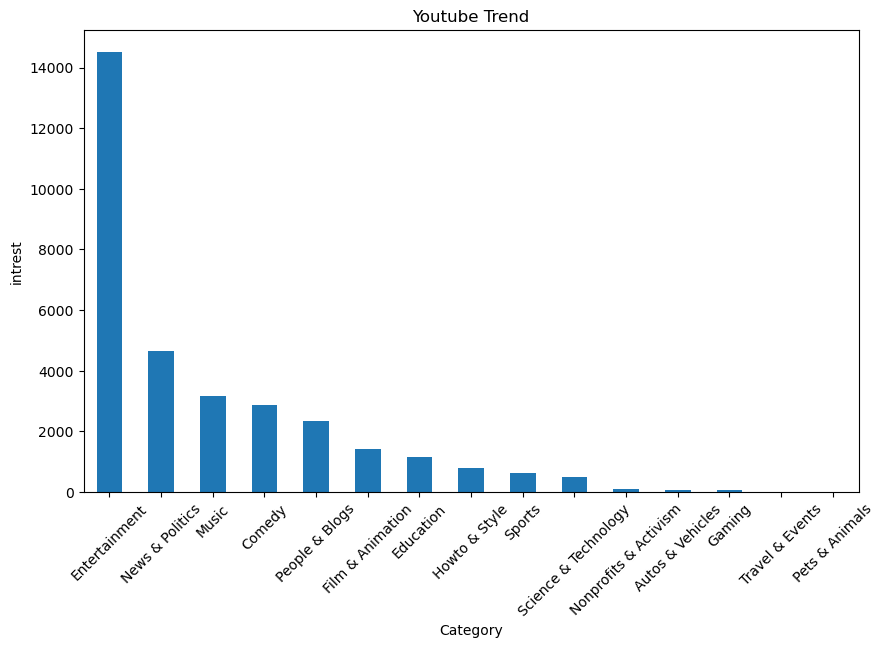

In [23]:
plt.figure(figsize=(10, 6))
top_categories.plot(kind='bar')
plt.title("Youtube Trend")
plt.xlabel('Category')
plt.ylabel('intrest')
plt.xticks(rotation=45)
plt.show()

In [24]:
print(df['publish_day'].value_counts())

publish_day
Friday       5467
Saturday     5121
Thursday     4894
Tuesday      4522
Monday       4476
Wednesday    4466
Sunday       3512
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Friday'),
  Text(1, 0, 'Saturday'),
  Text(2, 0, 'Thursday'),
  Text(3, 0, 'Tuesday'),
  Text(4, 0, 'Monday'),
  Text(5, 0, 'Wednesday'),
  Text(6, 0, 'Sunday')])

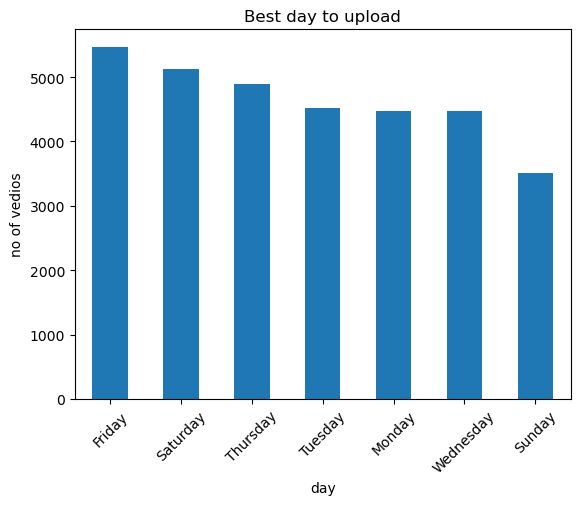

In [25]:

top_day=df['publish_day'].value_counts().head(10)
top_day.plot(kind='bar')
plt.title("Best day to upload")
plt.xlabel("day")
plt.ylabel("no of vedios")
plt.xticks(rotation=45)



(array([-2.0e+07,  0.0e+00,  2.0e+07,  4.0e+07,  6.0e+07,  8.0e+07,
         1.0e+08,  1.2e+08,  1.4e+08]),
 [Text(-20000000.0, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(20000000.0, 0, '0.2'),
  Text(40000000.0, 0, '0.4'),
  Text(60000000.0, 0, '0.6'),
  Text(80000000.0, 0, '0.8'),
  Text(100000000.0, 0, '1.0'),
  Text(120000000.0, 0, '1.2'),
  Text(140000000.0, 0, '1.4')])

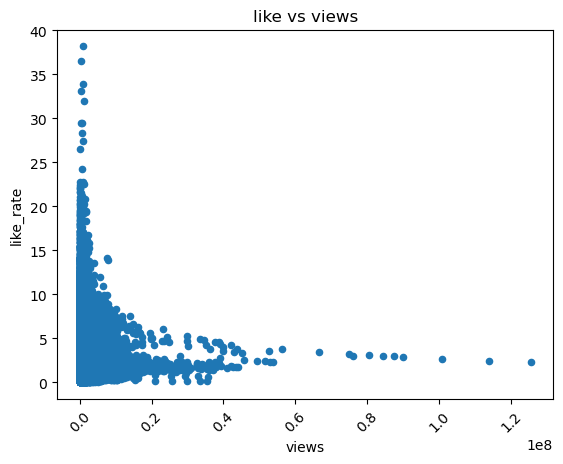

In [26]:
df.plot(kind='scatter', x='views', y='like_rate')
plt.title("like vs views")
plt.xticks(rotation=45)





(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '14'),
  Text(1, 0, '12'),
  Text(2, 0, '13'),
  Text(3, 0, '11'),
  Text(4, 0, '6'),
  Text(5, 0, '16'),
  Text(6, 0, '5'),
  Text(7, 0, '15'),
  Text(8, 0, '7'),
  Text(9, 0, '10')])

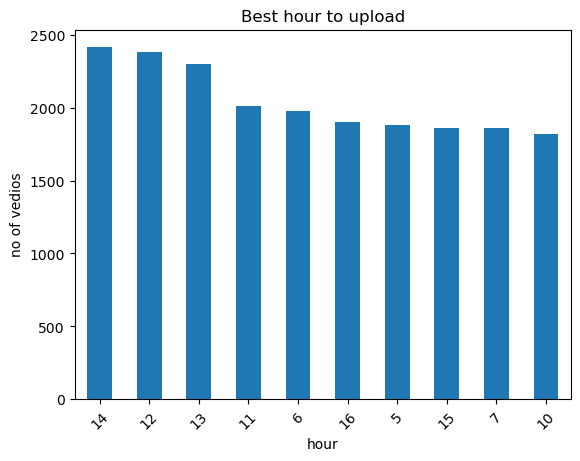

In [27]:
top_hour=df['publish_hour'].value_counts().head(10)
top_hour.plot(kind='bar')
plt.title("Best hour to upload")
plt.xlabel("hour")
plt.ylabel("no of vedios")
plt.xticks(rotation=45)
              





(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '14'),
  Text(1, 0, '12'),
  Text(2, 0, '13'),
  Text(3, 0, '11'),
  Text(4, 0, '6'),
  Text(5, 0, '16'),
  Text(6, 0, '5'),
  Text(7, 0, '15'),
  Text(8, 0, '7'),
  Text(9, 0, '10')])

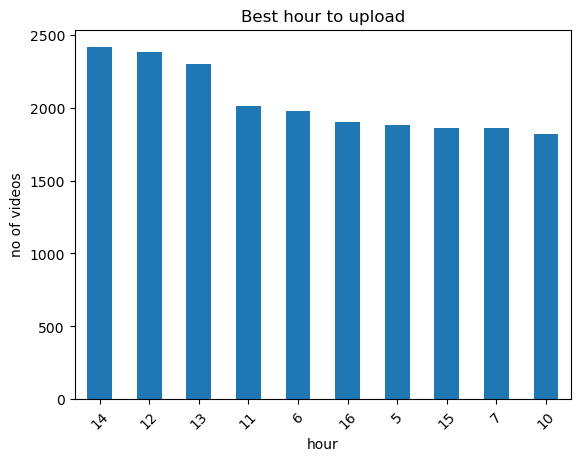

In [28]:
top_hour = df['publish_hour'].value_counts().head(10)  # Fixed: value_counts() instead of value_count()
top_hour.plot(kind='bar')
plt.title("Best hour to upload")
plt.xlabel("hour")
plt.ylabel("no of videos")  # Note: fixed spelling of "videos"
plt.xticks(rotation=45)

In [29]:
top_ten=df.groupby('channel_title')['views'].mean().sort_values(ascending=False).head(10)

In [30]:
df.groupby('channel_title')['video_id'].count().sort_values(ascending=False).head(10)

channel_title
etvteluguindia        204
VikatanTV             202
Flowers Comedy        201
ETV Plus India        201
Study IQ education    200
Tarang TV             199
SAB TV                198
SET India             194
Mazhavil Manorama     194
RadaanMedia           192
Name: video_id, dtype: int64

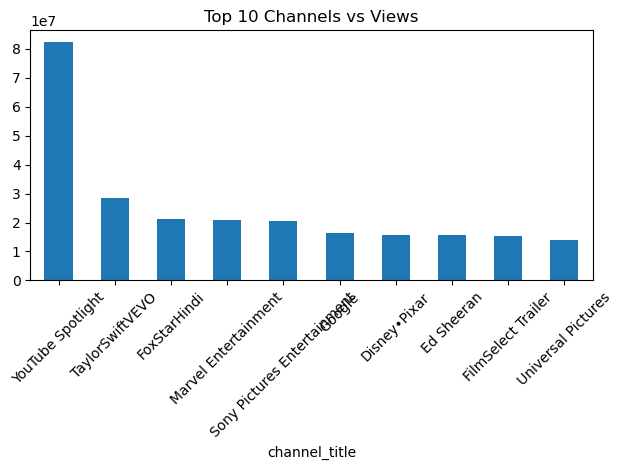

In [31]:

top_ten.plot(kind='bar')
plt.title("Top 10 Channels vs Views")

plt.xticks(rotation=45)
plt.tight_layout()

In [32]:
df.to_csv(r'C:\Users\user\Downloads\clean_trending.csv', index=False)
print("Saved!")

Saved!


In [35]:
summary = df.groupby('category_name').agg(
    total_views=('views', 'sum'),
    avg_views=('views', 'mean'),
    avg_like_rate=('like_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2).reset_index()

summary.to_excel(r'C:\Users\user\Downloads\youtube_summary.xlsx', index=False)
print("Saved!")

Saved!
